In [495]:
# --- IMPORT STATEMENTS ---

import numpy as np

import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

from photutils.detection import DAOStarFinder
import healpy as hp

In [496]:
# --- GLOBAL VARIABLES ---

LINUX_DIRECTORY = "/home/aimee/mphys"
FIGURE_SAVEDIR = "figures/masking"
MASKED_MAPS_SAVEDIR = f'{LINUX_DIRECTORY}/data/masked_maps'
SAVE_FIGS = True

SNR_CSV_PATH = f'{LINUX_DIRECTORY}/data/SNRs_final.csv'
PS_CSV_PATH = f'{LINUX_DIRECTORY}/data/point_sources_final.csv'

L_BOUNDS = [15, 32] # degrees
B_BOUNDS = [-1.5, 1.5] # degrees

# Locating point sources (tweak) - see locate_point_sources()
FWHM_PS = 5
THRESHOLD_FACTOR = 0.8

# Maps and locations

GDIGS_MOSAIC_DIR = f"{LINUX_DIRECTORY}/data/GDIGS_mosaic"
OTHER_MAPS_DIR = f'{LINUX_DIRECTORY}/data/maps'

COMAP_MAPS = {
    "COMAP 26.5 GHz": "comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 27.5 GHz": "comap_160625_band01_band01_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 28.5 GHz": "comap_160625_band02_band02_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 29.5 GHz": "comap_160625_band03_band03_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 30.5 GHz": "comap_160625_band04_band04_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 31.5 GHz": "comap_160625_band05_band05_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 32.5 GHz": "comap_160625_band06_band06_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 33.5 GHz": "comap_160625_band07_band07_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits"
}
COMAP_KEYS = list(COMAP_MAPS.keys())

EFFELSBERG_MAPS = {
    "Effelsberg 1.43 GHz (10')":"EFFELSBERG-1.4285714285714286GHz-10.0amin.fits",
    "Effelsberg 1.43 GHz (15')":"EFFELSBERG-1.4285714285714286GHz-15.0amin.fits",
    "Effelsberg 1.43 GHz (20')":"EFFELSBERG-1.4285714285714286GHz-20.0amin.fits",
    "Effelsberg 1.43 GHz (25')":"EFFELSBERG-1.4285714285714286GHz-25.0amin.fits",
    "Effelsberg 1.43 GHz (30')":"EFFELSBERG-1.4285714285714286GHz-30.0amin.fits",
    "Effelsberg 1.43 GHz (60')":"EFFELSBERG-1.4285714285714286GHz-60.0amin.fits",
    "Effelsberg 2.73 GHz (5')":"EFFELSBERG-2.7272727272727275GHz-5.0amin.fits",
    "Effelsberg 2.73 GHz (10')":"EFFELSBERG-2.7272727272727275GHz-10.0amin.fits",
    "Effelsberg 2.73 GHz (15')":"EFFELSBERG-2.7272727272727275GHz-15.0amin.fits",
    "Effelsberg 2.73 GHz (20')":"EFFELSBERG-2.7272727272727275GHz-20.0amin.fits",
    "Effelsberg 2.73 GHz (25')":"EFFELSBERG-2.7272727272727275GHz-25.0amin.fits",
    "Effelsberg 2.73 GHz (30')":"EFFELSBERG-2.7272727272727275GHz-30.0amin.fits",
    "Effelsberg 2.73 GHz (60')":"EFFELSBERG-2.7272727272727275GHz-60.0amin.fits"
}
EFFELSBERG_KEYS = list(EFFELSBERG_MAPS.keys())
# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index

NOBEYAMA_MAPS = {

}

PARKES_MAPS = {
    "PARKES 5GHz (5')":"PARKES-5.0GHz-5.0amin.fits",
    "PARKES 5GHz (10')":"PARKES-5.0GHz-10.0amin.fits"
}
PARKES_KEYS = list(PARKES_MAPS.keys())


In [497]:
# --- FUNCTION DEFINTIONS ---

In [498]:
def get_map(path, l_bounds=None, b_bounds=None, noise_index=3): # from maps_processing.ipynb
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    # DEBUG
    for i, hdu in enumerate(fits_file):
        print(f"HDU {i} header:")
        print(hdu.header)
    # /DEBUG 

    data = fits_file[0].data * 1000 # convert to mK

    try: # debug for no noise layer
        noise = 1/fits_file[noise_index].data * 1000 # convert to mK
    except IndexError:
        noise = None

    header = fits_file[0].header
    wcs = WCS(header)

    if l_bounds and b_bounds is not None:
        upper_l, lower_b = wcs.all_world2pix(l_bounds[0], b_bounds[0], 0)
        lower_l, upper_b = wcs.all_world2pix(l_bounds[1], b_bounds[1], 0)

        cutout = data[int(lower_b):int(upper_b)+1,
                      int(lower_l):int(upper_l)+1].copy()
        
        if noise:  # debug for no noise layer
            cutout_noise = noise[int(lower_b):int(upper_b)+1,
                                int(lower_l):int(upper_l)+1].copy()
        else:
            cutout_noise = None

        cutout[cutout==np.nan] = 0

        new_header = fits.Header()
        new_header['CTYPE1'] = wcs.wcs.ctype[0]
        new_header['CTYPE2'] = wcs.wcs.ctype[1]
        new_header['CRVAL1'] = l_bounds[1]
        new_header['CRVAL2'] = b_bounds[0]
        new_header['CRPIX1'] = 1
        new_header['CRPIX2'] = 1
        new_header['PC1_1'] = 1.0
        new_header['PC1_2'] = 0.0
        new_header['PC2_1'] = 0.0
        new_header['PC2_2'] = 1.0
        new_header['CDELT1'] = header['CDELT1']
        new_header['CDELT2'] = header['CDELT2']
        new_header['NAXIS1'] = upper_l - lower_l
        new_header['NAXIS2'] = upper_b - lower_b
        new_wcs = WCS(new_header)
        print(f"Cutout WCS:\n {new_wcs}")

        return cutout, cutout_noise, new_header, new_wcs
    
    else:
        print("Raw WCS:\n {wcs}")
        
        return data, noise, header, wcs

In [499]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = -0.01 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if SAVE_FIGS:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [500]:
def find_point_sources(file_path):
    
    data = np.genfromtxt(file_path, delimiter=',', skip_header=1, dtype=float)
    l_arr = data[:,0]
    b_arr = data[:,1]
    radius_arr = data[:,2]

    return l_arr, b_arr, radius_arr    

In [501]:
def create_point_source_mask(fits_data, x_coords, y_coords, fwhm, show_mask=False):

    # Calculate sigma from FWHM
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))

    # Create meshgrid corresponding to image coords
    y, x = np.indices(fits_data.shape)

    # Create mask
    mask = np.zeros(fits_data.shape, dtype=bool) # empty, same shape as GDIGS mosaic
    for x_c, y_c in zip(x_coords, y_coords):
        distance = np.sqrt((x - x_c)**2 + (y - y_c)**2) 
        mask = np.logical_or(mask, distance < 3*sigma)  # if pixel is < 3*sigma away from centre of point source (i.e. inside Gaussian), mask it

    if show_mask: # quick plot, can expand to convert coords, add axis labels, etc. if necessary
        plt.imshow(mask, origin='lower', cmap='gray')
        plt.title('Point Source Mask')
        plt.show()
    
    return mask

In [502]:
def find_SNRs(file_path = SNR_CSV_PATH):

    data = np.genfromtxt(file_path, delimiter=',', skip_header=1, dtype=float)
    l = data[:,0]
    b = data[:,1]
    x_radius = data[:,2] / 2
    y_radius = data[:,3] / 3
    
    return l, b, x_radius, y_radius

In [503]:
def galactic_to_pixel(l_coords, b_coords, WCS):

    x_coords = []
    y_coords = []
    for i, _ in enumerate(l_coords):
        l = l_coords[i] 
        b = b_coords[i]
        
        x, y = WCS.all_world2pix(float(l), float(b), 0)

        x_coords.append(x)
        y_coords.append(y)

    return x_coords, y_coords

In [504]:
def create_snr_mask(fits_data, x_coords, y_coords, x_radii, y_radii, show_mask=False):

    # Create meshgrid corresponding to image coords
    y, x = np.indices(fits_data.shape)

    # Create mask
    mask = np.zeros(fits_data.shape, dtype=bool) # empty, same shape as GDIGS mosaic
    for x_c, y_c, x_rad, y_rad in zip(x_coords, y_coords, x_radii, y_radii):

        ellipse_condition = ((x - x_c) ** 2) / (x_rad ** 2) + ((y - y_c) ** 2) / (y_rad ** 2) <= 1
        mask = np.logical_or(mask, ellipse_condition) # if pixel within SNR ellipse, mask it
    
    if show_mask:
        plt.imshow(mask, origin='lower', cmap='gray')
        plt.title('SNR Mask')
        plt.show()

    return mask

In [505]:
def create_mask(data, wcs, map_title, show_plots=False):

    # Mask point sources
    l_ps, b_ps, radii_ps = find_point_sources(file_path=PS_CSV_PATH)
    x_ps, y_ps = galactic_to_pixel(l_ps, b_ps, WCS=wcs)
    radii_ps = np.array(radii_ps) / 2 # HARD CODED - bug w/ reprojected map
    
    if show_plots:
        plot_fits(data, wcs, x_coords=x_ps, y_coords=y_ps, title=f'{map_title} - Point Sources Locations')
    mask_ps = create_point_source_mask(data, x_ps, y_ps, fwhm=radii_ps[0], show_mask=show_plots)
    if show_plots:
        data_ps = data.copy()
        data_ps[mask_ps] = hp.UNSEEN
        plot_fits(data_ps, wcs, title=f'{map_title} - Point Sources Masked')

    # Mask supernova remnants
    x_snr, y_snr, x_radii, y_radii = find_SNRs(file_path=SNR_CSV_PATH)
    x_snr, y_snr = galactic_to_pixel(x_snr, y_snr, wcs)
    x_radii = np.array(x_radii) / 2 # HARD CODED - bug w/ reprojected map
    y_radii = np.array(y_radii) / 2 # HARD CODED - bug w/ reprojected map

    if show_plots:
        plot_fits(data, wcs, x_coords=x_snr, y_coords=y_snr, title=f'{map_title} - SNR Locations')
    
    mask_snr = create_snr_mask(data, x_snr, y_snr, x_radii, y_radii, show_mask=show_plots)

    if show_plots:
        data_snr = data.copy()
        data_snr[mask_snr] = hp.UNSEEN
        plot_fits(data_snr, wcs, title=f'{map_title} - SNRs Masked')

    # Apply both masks
    mask_ps_snr = mask_ps | mask_snr # combine both masks
    data_ps_snr = data.copy()
    data_ps_snr[mask_ps_snr] = hp.UNSEEN
    plot_fits(data_ps_snr, wcs, title=f'{map_title} - SNRs and Point Sources Masked')

    return data_ps_snr

In [506]:
def cut_data(data, wcs, header):
    lat_min = B_BOUNDS[0]
    lat_max = B_BOUNDS[1]
    long_min = L_BOUNDS[0]
    long_max = L_BOUNDS[1]
    step = header['CDELT2']  # pixel resolution

    start_row = int(header['CRPIX2'] + lat_min / step)
    end_row   = int(header['CRPIX2'] + lat_max / step)
    start_col = int(header['CRPIX1'] + (header['CRVAL1'] - long_max) / step)
    end_col   = int(header['CRPIX1'] + (header['CRVAL1'] - long_min) / step)
    
    # Safety check against invalid indices
    nrows, ncols = data.shape
    start_row = max(0, min(nrows - 1, start_row))
    end_row   = max(0, min(nrows - 1, end_row))
    start_col = max(0, min(ncols - 1, start_col))
    end_col   = max(0, min(ncols - 1, end_col))
    
    # Extract and process submap
    submap = data[start_row:end_row + 1, start_col:end_col + 1].copy()
    submap[submap == 0] = np.nan

    wcs.wcs.crpix[0] -= start_col
    wcs.wcs.crpix[1] -= start_row
    
    return submap, wcs

Getting data from /home/aimee/mphys/data/GDIGS_mosaic/gdigs_mosaic_1arcmin.fits
HDU 0 header:
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1077                                                  NAXIS2  =                  182                                                  WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =                538.5 / Pixel coordinate of reference point            CRPIX2  =                 91.0 / Pixel coordinate of reference point            CDELT1  =   -0.016666666666667 / [deg] Coordinate increment at reference point  CDELT2  =    0.016666666666667 / [deg] Coordinate increment at reference point  CUNIT1  = 'deg'                / Units of coordinate increment and value        CUNIT2  = 'deg'           

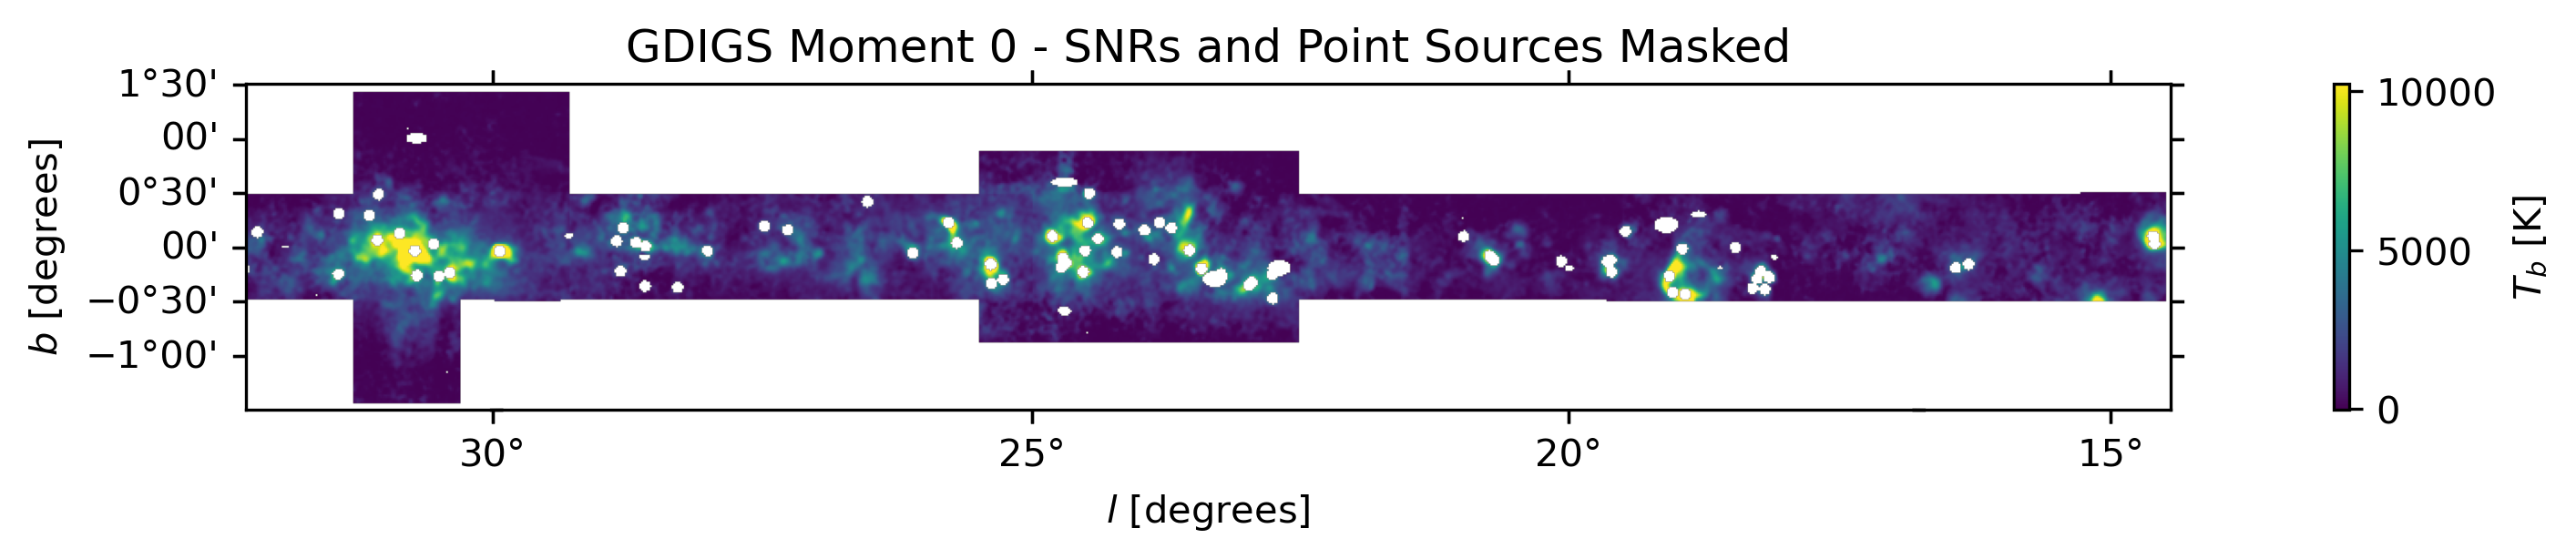

Getting data from /home/aimee/mphys/data/maps/PARKES-5.0GHz-5.0amin.fits
HDU 0 header:
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 3999                                                  NAXIS2  =                  799                                                  WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =               2000.0 / Pixel coordinate of reference point            CRPIX2  =                400.0 / Pixel coordinate of reference point            CDELT1  =   -0.016666666666667 / [deg] Coordinate increment at reference point  CDELT2  =    0.016666666666667 / [deg] Coordinate increment at reference point  CUNIT1  = 'deg'                / Units of coordinate increment and value        CUNIT2  = 'deg'                / 

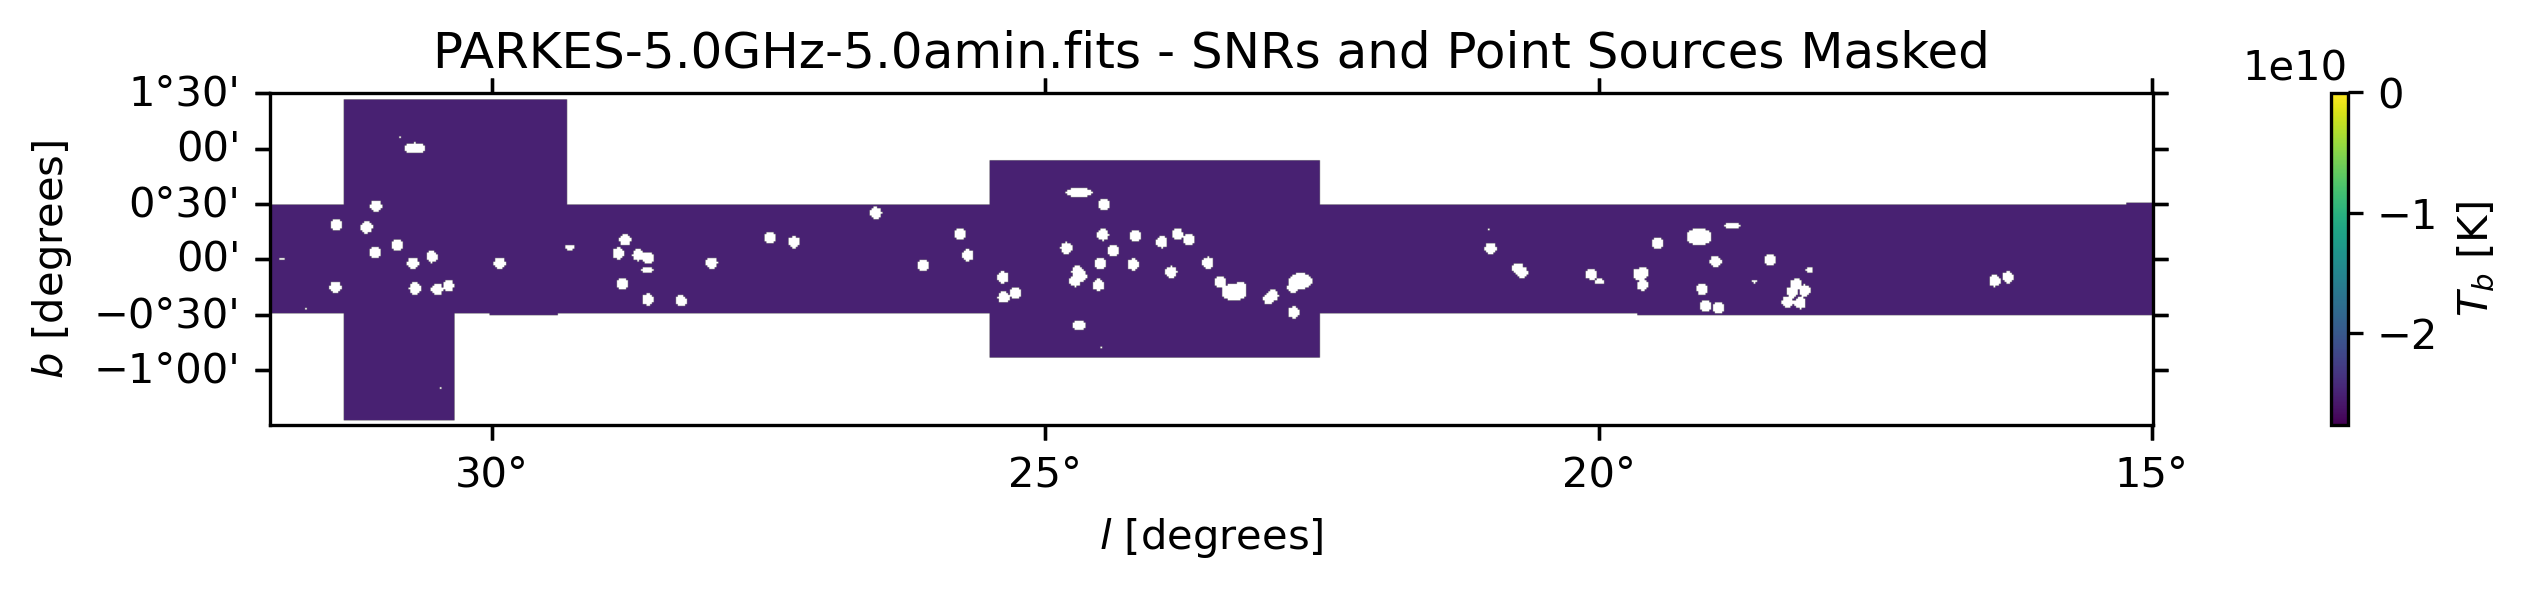

Getting data from /home/aimee/mphys/data/maps/PARKES-5.0GHz-10.0amin.fits
HDU 0 header:
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 3999                                                  NAXIS2  =                  799                                                  WCSAXES =                    2 / Number of coordinate axes                      CRPIX1  =               2000.0 / Pixel coordinate of reference point            CRPIX2  =                400.0 / Pixel coordinate of reference point            CDELT1  =   -0.016666666666667 / [deg] Coordinate increment at reference point  CDELT2  =    0.016666666666667 / [deg] Coordinate increment at reference point  CUNIT1  = 'deg'                / Units of coordinate increment and value        CUNIT2  = 'deg'                /

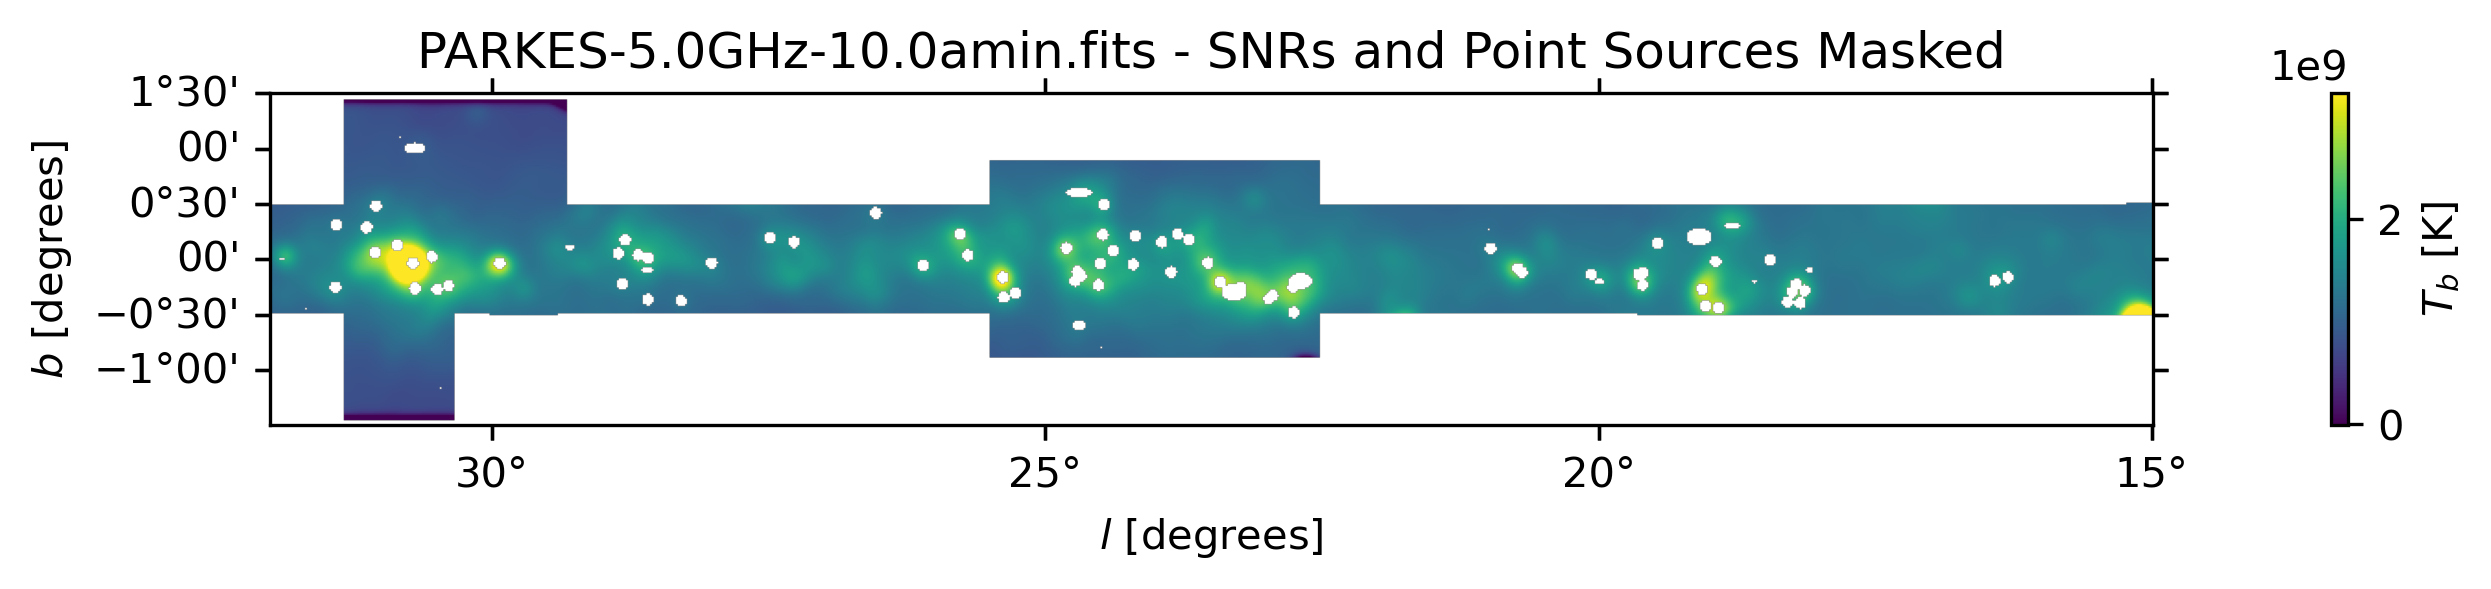

In [ ]:
# --- MAIN CODE ---

# Create GDIGS mosaic
mosaic, mosaic_noise, mosaic_header, mosaic_wcs = get_map(f'{GDIGS_MOSAIC_DIR}/gdigs_mosaic_1arcmin.fits')
# plot_fits(mosaic, mosaic_wcs, title='GDIGS Moment 0')
create_mask(mosaic, mosaic_wcs, map_title='GDIGS Moment 0', show_plots=False)

# Cut GDIGS mosaic to size
mosaic_submap, mosaic_submap_wcs = cut_data(mosaic, mosaic_wcs, mosaic_header)
# plot_fits(mosaic_submap, mosaic_submap_wcs, title='GDIGS Moment 0 Submap')
# create_mask(mosaic_submap, mosaic_submap_wcs, map_title='GDIGS Moment 0 Submap', show_plots=True)

map_gids = mosaic_submap.copy()
# map_gids = mosaic.copy()

map_names = []
# map_names.extend(EFFELSBERG_MAPS[fname] for fname in EFFELSBERG_KEYS)
map_names.extend(COMAP_MAPS[fname] for fname in COMAP_KEYS)
# map_names.extend(PARKES_MAPS[fname] for fname in PARKES_KEYS)

for map_name in map_names:
    map_path = f'{OTHER_MAPS_DIR}/{map_name}'
    data, noise, header, wcs = get_map(map_path)
    # cut data to GDIGS shape
    submap, wcs = cut_data(data, wcs, header)
    # mosaic = np.where(mosaic == hp.UNSEEN, np.nan, mosaic) # should be unnecessary?
    submap[np.isnan(map_gids)] = np.nan
    
    # mask PSs and SNRs
    masked_data = create_mask(submap, wcs, map_title=map_name, show_plots=False)

    # Save masked data as .fits file
    hdu = fits.PrimaryHDU(data=masked_data, header=header)
    hdu.writeto(f"{MASKED_MAPS_SAVEDIR}/{map_name.replace('.fits', '')}_masked.fits", overwrite=True)

